In [1]:
import pandas as pd
import numpy as np
import mygene
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

from pool_genes import *
from get_disorder_data import *
from enrichment_utils import *
from gradientVersion import *
from gsea import *

/home/gchan/kg98_scratch/gchan/SIR_SCZ/SIR_utils/.venv/lib/python3.14/site-packages/neuromaps/datasets/utils.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


In [23]:
from importlib import reload
import sys
if 'gradientVersion' in sys.modules:
    reload(sys.modules['gradientVersion'])
    print("Reloaded gradientVersion module")

Reloaded gradientVersion module


In [2]:
gene_expr = pd.read_csv('../../abagen_get/results/gene_expr_s132_indiv.csv')
gene_df = pd.read_csv('../data/251114_gene_pair_pvalues.csv')
gene_df["pass_all"] = (
    (gene_df["p_spatial_fdr"] < 0.05)
    & (gene_df["p_rewired_fdr"] < 0.05)
    & (gene_df["p_gene_fdr"] < 0.05)
).astype(int)

risk_df = pool_genes(gene_df, "risk gene")
risk_df = risk_df[risk_df["pass_all"] == True]

symbols = [g for g in risk_df["abagen symbol"] if g in gene_expr.columns]
risk_expr = gene_expr.loc[:, symbols]

# display(gene_expr.head())
# display(risk_df.head())

,AADAT,AAED1,AARS,AARS2,ABCA1,ABCA2,ABCA3,ABCA6,ABCB10,ABCC12,...,ZNF521,ZNF589,ZNF618,ZNF93,ZNHIT1,ZNRF2,ZNRF4,ZRANB2,ZRANB3,ZXDA
0,0.575301,0.510221,0.468108,0.680042,0.574975,0.522243,0.591299,0.491085,0.480072,0.536119,...,0.545838,0.561464,0.375920,0.520980,0.469409,0.642453,0.556703,0.523102,0.669487,0.461791
1,0.633474,0.386535,0.603526,0.667031,0.401738,0.676895,0.533126,0.706054,0.634173,0.490648,...,0.356365,0.465643,0.422261,0.460866,0.379574,0.473206,0.436800,0.679458,0.467777,0.446692
2,0.591744,0.450892,0.530764,0.709248,0.385967,0.513334,0.486285,0.577155,0.607663,0.502374,...,0.362291,0.519150,0.476338,0.348530,0.367504,0.541889,0.555314,0.569794,0.469153,0.466770
3,0.585251,0.349929,0.609207,0.646356,0.425108,0.477700,0.483973,0.702215,0.582783,0.484962,...,0.358353,0.496657,0.397477,0.349571,0.400681,0.401631,0.394428,0.733158,0.385434,0.571031
4,0.503452,0.422749,0.604103,0.687956,0.405712,0.452151,0.440637,0.777355,0.591358,0.382335,...,0.379052,0.458164,0.373789,0.323473,0.338008,0.409330,0.461599,0.755390,0.379278,0.452674


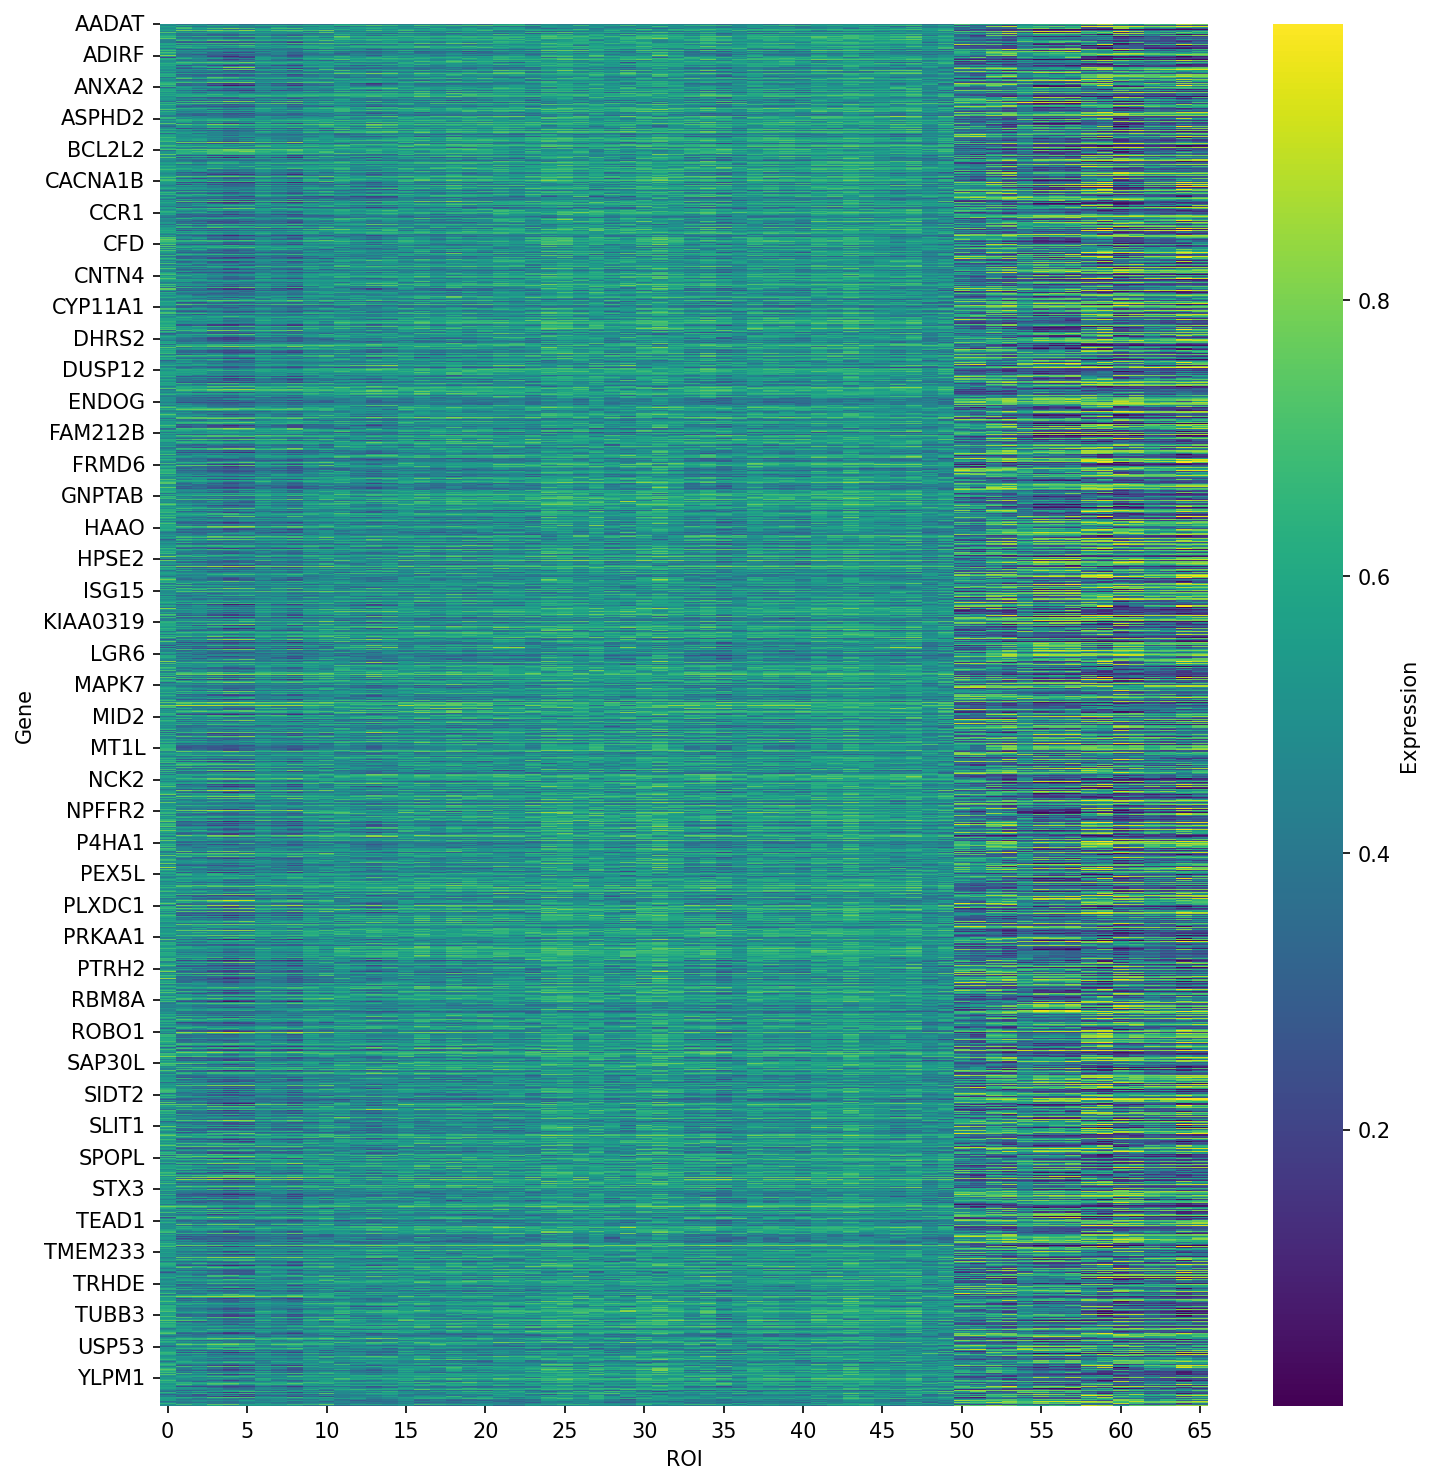

In [ ]:
display(risk_expr.head())
fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
risk_expr_plot = risk_expr.copy()
risk_expr_plot.index = risk_expr_plot.index + 1  # ROI labels start at 1

sns.heatmap(
    risk_expr_plot.T,          # genes on y-axis, ROI on x-axis
    cmap="viridis",
    ax=ax,
    cbar_kws={"label": "Expression"},
    xticklabels=5,
    yticklabels=50
)

ax.set_xlabel("ROI")
ax.set_ylabel("Gene")
plt.tight_layout()
plt.show()

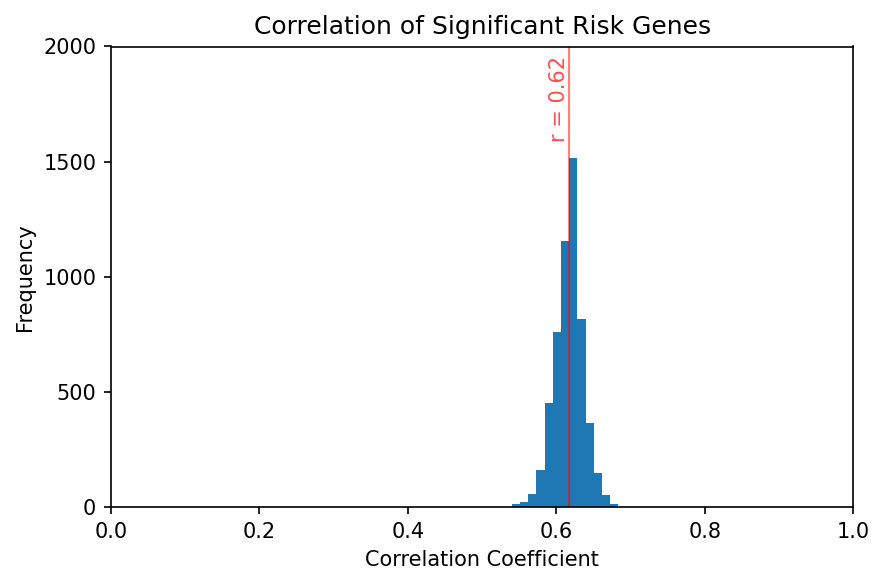

In [3]:
data = gene_df.loc[gene_df['pass_all'] == True, 'correlation'].dropna()

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
plt.hist(data, bins=15)
plt.xlim([0, 1])
plt.ylim([0, 2000])
plt.xlabel('Correlation Coefficient')
plt.ylabel('Frequency')
ax.axvline(data.mean(), color='Red', linewidth=1, alpha=0.5)
ax.text(data.mean(), 0.98, f'r = {data.mean():.2f}', color='r', ha='right', va='top', rotation=90,
        transform=ax.get_xaxis_transform(), alpha=0.7)
plt.title('Correlation of Significant Risk Genes')
ax.yaxis.set_major_locator(plt.MaxNLocator(4))

plt.tight_layout()
plt.show()

In [3]:
dme_results = gradientVersion(approach='dm', kernel='normalized_angle', alpha=1).fit(risk_expr)
pca_results = gradientVersion(approach='pca', kernel=None).fit(risk_expr)

print(dme_results.weights.shape)

New gradients version: method=dm, kernel=normalized_angle, sparsity=0, data=(data given)
New gradients version: method=pca, kernel=None, sparsity=0, data=(data given)
(2195, 5)


,C1,C2,C3,C4,C5
AADAT,-0.831858,-0.060377,0.091068,-0.291873,-0.173323
AAED1,0.866032,-0.251498,0.174345,-0.083596,0.137000
AARS,-0.922805,0.091092,-0.132282,-0.230921,0.144954
AARS2,-0.883259,0.103895,0.078126,0.147385,-0.171089
ABCA1,0.905148,-0.116695,0.217560,-0.164360,-0.153456


,C1,C2,C3,C4,C5
AADAT,0.826368,0.072844,0.104240,-0.312093,0.293794
AAED1,-0.865425,0.269147,0.134419,-0.060143,-0.233052
AARS,0.922539,-0.136195,-0.081751,-0.240023,-0.145370
AARS2,0.879828,-0.078990,0.085865,0.124060,0.273769
ABCA1,-0.908431,0.187644,0.195101,-0.159479,0.170607


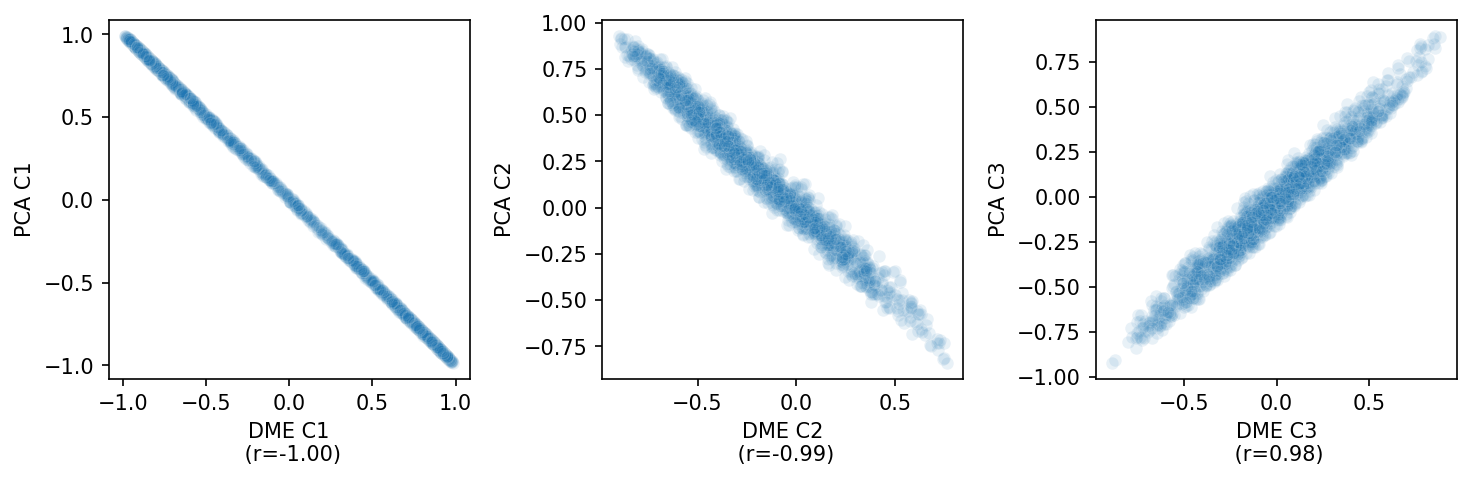

In [7]:
# display(risk_expr.head())
display(dme_results.weights.head())
display(pca_results.weights.head())

fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), dpi=150)
sns.scatterplot(x=dme_results.weights.iloc[:, 0], y=pca_results.weights.iloc[:, 0], ax=axes[0], alpha=0.1)
sns.scatterplot(x=dme_results.weights.iloc[:, 1], y=pca_results.weights.iloc[:, 1], ax=axes[1], alpha=0.1)
sns.scatterplot(x=dme_results.weights.iloc[:, 2], y=pca_results.weights.iloc[:, 2], ax=axes[2], alpha=0.1)
for i in range(3):
    axes[i].set_xlabel(f'DME C{i+1}\n (r={np.corrcoef(dme_results.weights.iloc[:, i], pca_results.weights.iloc[:, i])[0, 1]:.2f})')
    axes[i].set_ylabel(f'PCA C{i+1}')
plt.tight_layout()
plt.show()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
AADAT,0.021829,0.004042,0.007553,-0.025728,0.037488,-0.028017,-0.003531,-0.025038,-0.002624,-0.016556,0.024902,0.003557
AAED1,-0.019285,0.012600,0.008216,-0.004183,-0.025086,-0.002165,0.012404,0.006996,-0.011736,0.007300,-0.013010,0.004947
AARS,0.026221,-0.008132,-0.006374,-0.021290,-0.019958,-0.009056,-0.003138,0.004091,0.003177,0.018014,-0.018304,-0.011668
AARS2,0.025397,-0.004790,0.006799,0.011176,0.038173,-0.013552,-0.017158,-0.045274,-0.010030,-0.023782,-0.019451,0.024590
ABCA1,-0.029838,0.012948,0.017578,-0.016347,0.027068,0.011988,-0.017791,-0.002873,0.003247,-0.011475,0.003337,-0.026268


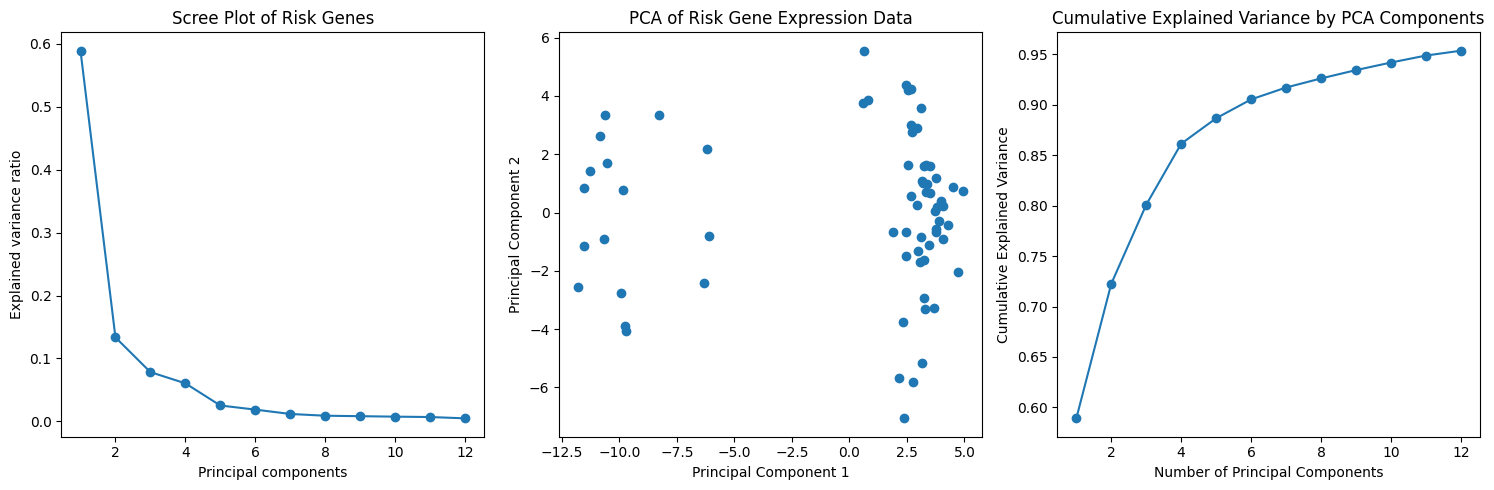

In [9]:

n_components = 12
# Run PCA
pca = PCA(n_components=n_components)
pca_result = pca.fit_transform(risk_expr)

pca_df = pd.DataFrame(data=pca_result, columns=[f'PC{i+1}' for i in range(n_components)], index=risk_expr.index)

# Output the loading of each gene onto the PCs
loadings = pd.DataFrame(pca.components_.T, columns=[f'PC{i+1}' for i in range(n_components)], index=symbols)
display(loadings.head())

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Scree plot
axs[0].plot(range(1, n_components + 1), pca.explained_variance_ratio_, marker='o')
axs[0].set_ylabel('Explained variance ratio')
axs[0].set_xlabel('Principal components')
axs[0].set_title('Scree Plot of Risk Genes')

# PCA scatter plot
axs[1].scatter(pca_df['PC1'], pca_df['PC2'])
axs[1].set_xlabel('Principal Component 1')
axs[1].set_ylabel('Principal Component 2')
axs[1].set_title('PCA of Risk Gene Expression Data')

# Plot cumulative explained variance ratio for PCA
cumulative_explained_var = np.cumsum(pca.explained_variance_ratio_)
axs[2].plot(range(1, n_components + 1), cumulative_explained_var, marker='o')
axs[2].set_xlabel('Number of Principal Components')
axs[2].set_ylabel('Cumulative Explained Variance')
axs[2].set_title('Cumulative Explained Variance by PCA Components')

plt.tight_layout()
plt.show()    

In [16]:
n_components = 4
weights = fit_weights(
    gene_expr, 
    # pca_df.iloc[:, :n_components], 
    dme_results.weights.iloc[:, :n_components],
    n_components=n_components
    )

# weights_out = weights.copy()
# weights_out['abagen symbol'] = weights_out.index
# weights_out = find_aliases(weights_out)
# weights_out.to_csv('../results/gene_pca_weights.csv', sep='\t', index=False)

null_weights = shuffle_gene_weights(weights, n=5000)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2195 is different from 66)

In [15]:
degs = get_deg_consensus()
deg_stats = compute_null_p(*compute_enrichments(weights, null_weights, degs))
display(deg_stats)
gwas_genes = get_gwas_combined()
gwas_stats = compute_null_p(*compute_enrichments(weights, null_weights, gwas_genes))
display(gwas_stats)

/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/enrichment_utils.py:152: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig,n_genes,n_matches
0,SCZ,C1,0.8460,0.110105,0.070061,0.039591,1.011448,True,0.3080,0.410667,False,506,321
1,SCZ,C2,0.9114,0.053134,0.025422,0.020584,1.346295,True,0.1772,0.354400,False,506,321
2,SCZ,C3,0.2680,-0.012641,-0.002252,0.016620,-0.625041,False,0.5360,0.536000,False,506,321
3,SCZ,C4,0.9904,0.010747,-0.022830,0.014803,2.268267,True,0.0192,0.076800,False,506,321


/fs04/scratch2/kg98/oldscratch/gchan/SIR_SCZ/SIR_utils/enrichment/scripts/enrichment_utils.py:152: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  .stack(0)


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig,n_genes,n_matches
0,SCZ,C1,0.9998,0.243012,0.071099,0.048451,3.548198,True,0.0004,0.001600,True,618,209
1,SCZ,C2,0.2256,0.006270,0.025542,0.025717,-0.749401,False,0.4512,0.451200,False,618,209
2,SCZ,C3,0.9668,0.036040,-0.002244,0.020682,1.851079,True,0.0664,0.088533,False,618,209
3,SCZ,C4,0.9812,0.015808,-0.022887,0.018435,2.098993,True,0.0376,0.075200,False,618,209


In [8]:
deg_gsea = run_gsea_df(weights, degs)
display(deg_gsea)
gwas_gsea = run_gsea_df(weights, gwas_genes)
display(gwas_gsea)

100%|██████████| 5000/5000 [00:11<00:00, 419.02it/s]


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig
0,SCZ,C1,0.8541,0.003818,0.001660,0.002246,0.960976,True,0.2918,0.583600,False
1,SCZ,C2,0.9960,0.011548,0.001602,0.002259,4.403476,True,0.0080,0.032000,True
2,SCZ,C3,0.6304,0.001707,0.001637,0.002316,0.030137,True,0.7392,0.739200,False
3,SCZ,C4,0.7464,0.002388,0.001630,0.002316,0.327220,True,0.5072,0.676267,False


100%|██████████| 5000/5000 [00:12<00:00, 412.54it/s]


,label,C,pct,true_mean,null_mean,null_std,z,pos,p,q,sig
0,SCZ,C1,0.3300,-0.000137,0.000330,0.000859,-0.543795,False,0.6600,0.660000,False
1,SCZ,C2,0.9009,0.001481,0.000320,0.000835,1.390970,True,0.1982,0.264267,False
2,SCZ,C3,0.9183,0.001618,0.000337,0.000864,1.482517,True,0.1634,0.264267,False
3,SCZ,C4,0.9393,0.001869,0.000332,0.000850,1.807391,True,0.1214,0.264267,False


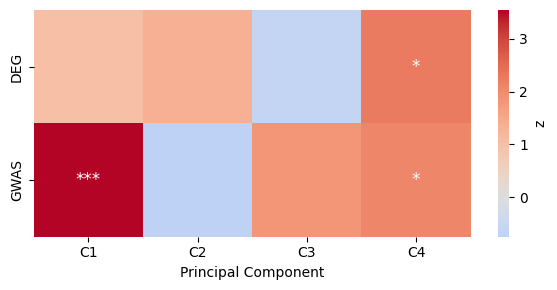

In [ ]:
import seaborn as sns
# Aggregate z and p_level per component for deg and gwas, then plot heatmap with p_level strings
def extract_aggregate(stats):
    z = stats.groupby('C')['z'].mean()
    p_min = stats.groupby('C')['q'].min()
    p_level = p_min.apply(lambda q: '***' if q < 0.001 else ('**' if q < 0.01 else ('*' if q < 0.05 else '')))
    return z, p_level

deg_z, deg_p = extract_aggregate(deg_stats)
gwas_z, gwas_p = extract_aggregate(gwas_stats)
# deg_z, deg_p = extract_aggregate(deg_gsea)
# gwas_z, gwas_p = extract_aggregate(gwas_gsea)

# Order components numerically (assumes names like 'C1','C2',...)
components = sorted(set(deg_z.index).union(gwas_z.index), key=lambda x: int(x.strip('C')))
deg_z = deg_z.reindex(components).fillna(0)
gwas_z = gwas_z.reindex(components).fillna(0)
deg_p = deg_p.reindex(components).fillna('')
gwas_p = gwas_p.reindex(components).fillna('')

heat_df = pd.DataFrame([deg_z.values, gwas_z.values], index=['deg','gwas'], columns=components)

fig, ax = plt.subplots(figsize=(max(6, len(components)*0.6), 3))
sns.heatmap(heat_df, cmap='coolwarm', center=0, cbar_kws={'label': 'z'}, ax=ax, xticklabels=components, yticklabels=['DEG','GWAS'])
ax.set_xlabel('Principal Component')
ax.set_ylabel('')

# Overlay p_level strings where present
for i, row in enumerate(heat_df.index):
    for j, comp in enumerate(components):
        p = deg_p[comp] if row == 'deg' else gwas_p[comp]
        if p:
            ax.text(j + 0.5, i + 0.5, p, ha='center', va='center', color='white', fontsize=12)

plt.tight_layout()
plt.savefig('../results/gene_pca_enrichment_heatmap.svg', bbox_inches='tight')
plt.show()

,component,variance_explained,percent_explained
0,0,31.346697,58.736865
1,1,6.878097,12.888051
2,2,4.202847,7.875217
3,3,3.153457,5.908890
4,4,1.172932,2.197818


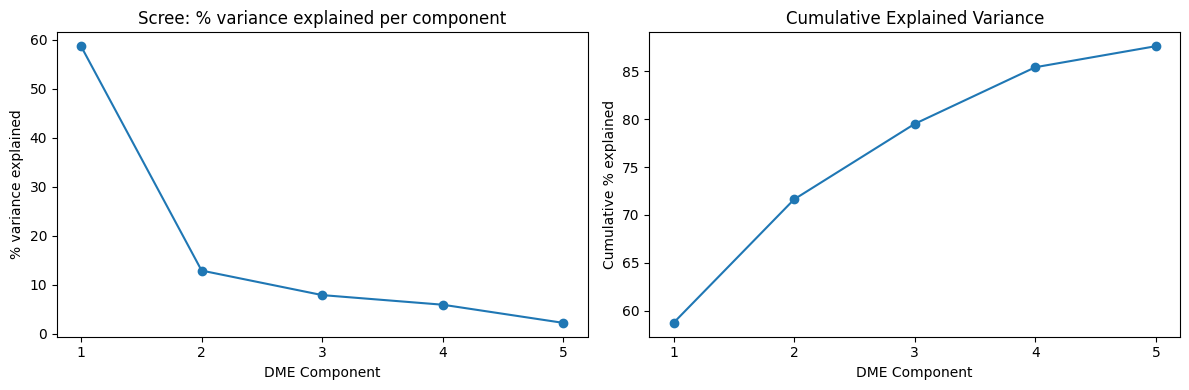

In [ ]:
# Compute variance explained per DME component using provided regress/get_var_explained pattern
# This defines regress_out_components and a generalized get_var_explained, then uses them on dme_results
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


def regress_out_components(version, n_components=1, norm=False):
    """
    Regress spatial patterns of n components out of the region-by-gene expression matrix
    version: object with attributes `expression` (DataFrame region x gene) and `scores` (DataFrame region x components)
    Returns residuals as a DataFrame with the same shape as `version.expression`.
    """
    data = version.expression
    components = version.scores.iloc[:, 0:n_components]
    lm = LinearRegression().fit(components.values, data.values)
    estimated_data = lm.predict(components.values)
    residuals = pd.DataFrame(data - estimated_data, index=data.index, columns=data.columns)

    if norm:
        residuals = residuals.apply(lambda x: (x - np.mean(x)) / np.std(x, ddof=0))
    return residuals


def get_var_explained(version, max_components=None, norm=False):
    """
    Compute variance explained of components by successively computing total variance of residuals.
    Returns DataFrame with variance explained and percent explained for each component 1..K where K is max_components or available components.
    """
    n_available = version.scores.shape[1]
    if max_components is None:
        max_components = n_available
    max_components = min(max_components, n_available)

    original_var = version.expression.var(ddof=0).sum()
    V_prev = original_var
    VE_list = []
    V_list = [original_var]

    for i in range(1, max_components + 1):
        resid = regress_out_components(version, n_components=i, norm=norm)
        Vi = resid.var(ddof=0).sum()
        VE = V_prev - Vi
        VE_list.append(VE)
        V_list.append(Vi)
        V_prev = Vi

    comp_names = list(version.scores.columns[:len(VE_list)]) if hasattr(version.scores, 'columns') else [f'C{i+1}' for i in range(len(VE_list))]
    VE_array = np.array(VE_list)
    percent = 100.0 * VE_array / original_var

    df = pd.DataFrame({'component': comp_names, 'variance_explained': VE_array, 'percent_explained': percent})
    return df


# Run on dme_results (expects dme_results to have `.expression` and `.scores`).
# If attribute names differ, try fallbacks using `weights` and `risk_expr`.
try:
    ve_df = get_var_explained(dme_results, max_components=dme_results.scores.shape[1])
except Exception:
    # try constructing a simple version-like object from what we have
    class _TmpVersion:
        pass
    v = _TmpVersion()
    # expression: regions x genes
    v.expression = risk_expr.copy()
    # scores: use dme_results.weights if present
    try:
        v.scores = dme_results.weights.copy()
    except Exception:
        # last resort: try pca_results
        v.scores = pca_results.weights.copy()
    ve_df = get_var_explained(v, max_components=v.scores.shape[1])

# Display table
display(ve_df)

# Scree plot (percent explained per component) and cumulative explained variance
percent = ve_df['percent_explained'].values
cum_percent = np.cumsum(percent)
components = ve_df['component'].values + 1

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Scree 
axes[0].plot(components, percent, marker='o')
axes[0].set_xticks(components)
axes[0].set_ylabel('% variance explained')
axes[0].set_xlabel('DME Component')
axes[0].set_title('Scree: % variance explained per component')

# Cumulative explained variance 
axes[1].plot(components, cum_percent, marker='o')
axes[1].set_xticks(components)
axes[1].set_ylabel('Cumulative % explained')
axes[1].set_xlabel('DME Component')
axes[1].set_title('Cumulative Explained Variance')

plt.tight_layout()
plt.show()
